In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [5]:
NUM_CLASSES = 10
SAMPLES_PER_CLASS = [5000, 2500, 1250, 625, 312, 156, 78, 39, 20, 10]

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
full_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

imbalanced_data = []
imbalanced_targets = []
for class_idx, n_samples in enumerate(SAMPLES_PER_CLASS):
    idx = (full_mnist.targets == class_idx).nonzero(as_tuple=True)[0]
    selected = idx[:n_samples]
    imbalanced_data.append(full_mnist.data[selected])
    imbalanced_targets.append(full_mnist.targets[selected])

X_imbalanced = torch.cat(imbalanced_data, dim=0).float().view(-1, 28*28) / 255.0
y_imbalanced = torch.cat(imbalanced_targets, dim=0)

perm = torch.randperm(len(X_imbalanced))
X_imbalanced, y_imbalanced = X_imbalanced[perm], y_imbalanced[perm]

print(f"Imbalanced dataset size: {len(X_imbalanced)}")
print(f"Class distribution: {Counter(y_imbalanced.tolist())}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


Imbalanced dataset size: 9990
Class distribution: Counter({0: 5000, 1: 2500, 2: 1250, 3: 625, 4: 312, 5: 156, 6: 78, 7: 39, 8: 20, 9: 10})


In [6]:
class LinearModel(nn.Module):
    def __init__(self, input_dim=784, num_classes=10):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.linear(x)

def train_and_evaluate(model, X, y, optimizer_name='sgd', lr=0.01, epochs=500, batch_size=128):
    model = model.to(device)
    X, y = X.to(device), y.to(device)
    criterion = nn.CrossEntropyLoss(reduction='none')

    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr)

    history = {'loss': [], 'per_class_loss': np.full((epochs, 10), np.nan)}

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X))
        epoch_loss = 0
        batches = 0
        per_class_sum = torch.zeros(10, device=device)
        per_class_cnt = torch.zeros(10, device=device)

        for i in range(0, len(X), batch_size):
            idx = perm[i:i+batch_size]
            x_batch, y_batch = X[idx], y[idx]

            logits = model(x_batch)
            loss_per_sample = criterion(logits, y_batch)
            loss = loss_per_sample.mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batches += 1

            with torch.no_grad():
                for c in range(10):
                    mask = (y_batch == c)
                    if mask.sum() > 0:
                        per_class_sum[c] += loss_per_sample[mask].sum()
                        per_class_cnt[c] += mask.sum()

        history['loss'].append(epoch_loss / batches)

        for c in range(10):
            if per_class_cnt[c] > 0:
                history['per_class_loss'][epoch, c] = (per_class_sum[c] / per_class_cnt[c]).cpu().item()

        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {history['loss'][-1]:.4f}")

    return model, history

print("=== SGD ===")
model_sgd_lin, hist_sgd_lin = train_and_evaluate(LinearModel(), X_imbalanced, y_imbalanced, 'sgd', lr=0.1, epochs=500)

print("\n=== Adam ===")
model_adam_lin, hist_adam_lin = train_and_evaluate(LinearModel(), X_imbalanced, y_imbalanced, 'adam', lr=0.001, epochs=500)

=== SGD ===
Epoch 100/500, Loss: 0.0734
Epoch 200/500, Loss: 0.0533
Epoch 300/500, Loss: 0.0446
Epoch 400/500, Loss: 0.0388
Epoch 500/500, Loss: 0.0344

=== Adam ===
Epoch 100/500, Loss: 0.0329
Epoch 200/500, Loss: 0.0142
Epoch 300/500, Loss: 0.0069
Epoch 400/500, Loss: 0.0034
Epoch 500/500, Loss: 0.0017


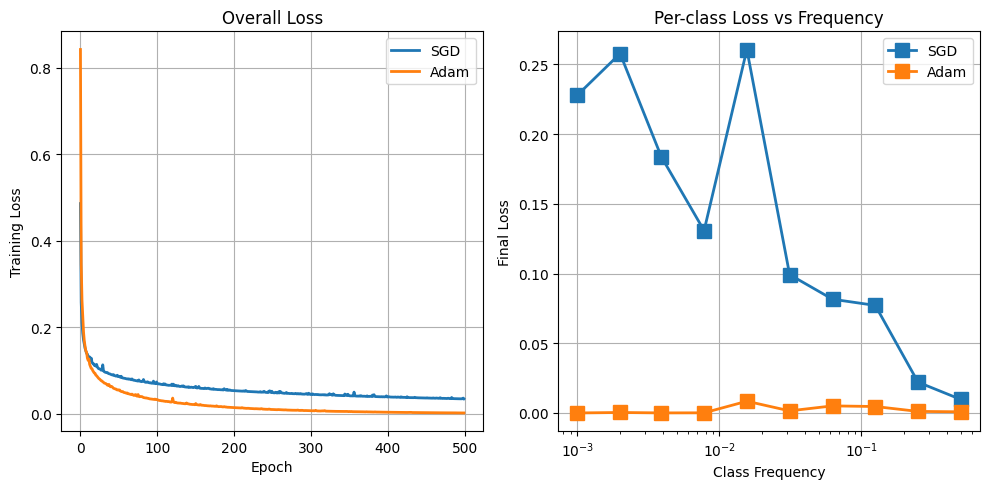

In [7]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_sgd_lin['loss'], label='SGD', linewidth=2)
plt.plot(hist_adam_lin['loss'], label='Adam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(True)
plt.title('Overall Loss')

plt.subplot(1, 2, 2)

class_freqs = np.array(SAMPLES_PER_CLASS) / sum(SAMPLES_PER_CLASS)
sgd_final = hist_sgd_lin['per_class_loss'][-1]
adam_final = hist_adam_lin['per_class_loss'][-1]

plt.semilogx(class_freqs, sgd_final, 's-', label='SGD', markersize=10, linewidth=2)
plt.semilogx(class_freqs, adam_final, 's-', label='Adam', markersize=10, linewidth=2)
plt.xlabel('Class Frequency')
plt.ylabel('Final Loss')
plt.legend()
plt.grid(True)
plt.title('Per-class Loss vs Frequency')

plt.tight_layout()
plt.show()

In [10]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 16*5*5)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

X_cnn = X_imbalanced.view(-1, 1, 28, 28)
y_cnn = y_imbalanced

print("=== CNN SGD ===")
model_sgd_cnn, hist_sgd_cnn = train_and_evaluate(LeNet5(), X_cnn, y_cnn, 'sgd', lr=0.01, epochs=500)

print("\n=== CNN Adam ===")
model_adam_cnn, hist_adam_cnn = train_and_evaluate(LeNet5(), X_cnn, y_cnn, 'adam', lr=0.0005, epochs=500)

=== CNN SGD ===
Epoch 100/500, Loss: 0.0407
Epoch 200/500, Loss: 0.0111
Epoch 300/500, Loss: 0.0033
Epoch 400/500, Loss: 0.0013
Epoch 500/500, Loss: 0.0007

=== CNN Adam ===
Epoch 100/500, Loss: 0.0001
Epoch 200/500, Loss: 0.0000
Epoch 300/500, Loss: 0.0000
Epoch 400/500, Loss: 0.0000
Epoch 500/500, Loss: 0.0000


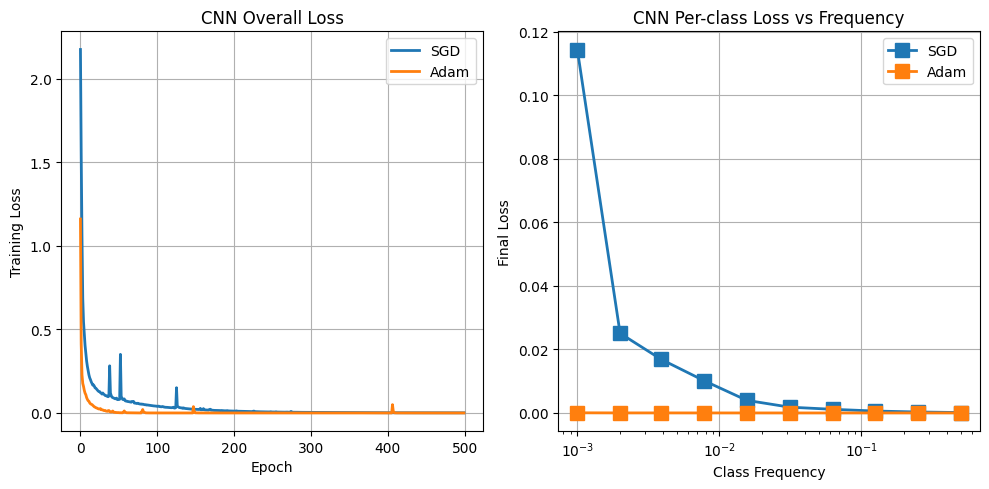

In [11]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_sgd_cnn['loss'], label='SGD', linewidth=2)
plt.plot(hist_adam_cnn['loss'], label='Adam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(True)
plt.title('CNN Overall Loss')

plt.subplot(1, 2, 2)
sgd_final_cnn = hist_sgd_cnn['per_class_loss'][-1]
adam_final_cnn = hist_adam_cnn['per_class_loss'][-1]

plt.semilogx(class_freqs, sgd_final_cnn, 's-', label='SGD', markersize=10, linewidth=2)
plt.semilogx(class_freqs, adam_final_cnn, 's-', label='Adam', markersize=10, linewidth=2)
plt.xlabel('Class Frequency')
plt.ylabel('Final Loss')
plt.legend()
plt.grid(True)
plt.title('CNN Per-class Loss vs Frequency')

plt.tight_layout()
plt.show()

In [12]:
def generate_synthetic_data(num_samples=5000, num_classes=100,
                            input_dim=64, alpha=1.0, noise_std=0.5):
    ranks = np.arange(1, num_classes + 1)
    probs = 1.0 / (ranks ** alpha)
    probs = probs / probs.sum()

    y = np.random.choice(num_classes, size=num_samples, p=probs)
    W_true = torch.randn(num_classes, input_dim) * 2.0
    X = W_true[y] + torch.randn(num_samples, input_dim) * noise_std

    return X.float(), torch.tensor(y, dtype=torch.long), probs


def train_synthetic(X, y, num_classes, optimizer_name='sgd', lr=0.01, epochs=200, batch_size=256):
    model = nn.Linear(X.shape[1], num_classes).to(device)
    X, y = X.to(device), y.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr) if optimizer_name == 'adam' else optim.SGD(model.parameters(), lr=lr)

    per_class_sum = torch.zeros(num_classes, device=device)
    per_class_cnt = torch.zeros(num_classes, device=device)
    history_loss = []

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X))
        epoch_loss = 0
        batches = 0

        for i in range(0, len(X), batch_size):
            idx = perm[i:i+batch_size]
            x_batch, y_batch = X[idx], y[idx]

            loss = criterion(model(x_batch), y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batches += 1

        history_loss.append(epoch_loss / batches)

        if (epoch+1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {history_loss[-1]:.4f}")

    model.eval()
    with torch.no_grad():
        logits = model(X)
        loss_per_sample = nn.CrossEntropyLoss(reduction='none')(logits, y)
        for c in range(num_classes):
            mask = (y == c)
            if mask.sum() > 0:
                per_class_sum[c] = loss_per_sample[mask].sum()
                per_class_cnt[c] = mask.sum()

    per_class_final = torch.where(per_class_cnt > 0, per_class_sum / per_class_cnt, torch.tensor(float('nan'))).cpu().numpy()

    return history_loss, per_class_final


print("Generating synthetic data...")
X_synth, y_synth, class_probs = generate_synthetic_data(
    num_samples=5000, num_classes=100, input_dim=64, alpha=1.0, noise_std=0.5
)
print(f"X: {X_synth.shape}, Classes: {len(torch.unique(y_synth))}")

print("\n=== SGD ===")
loss_sgd, perclass_sgd = train_synthetic(X_synth, y_synth, 100, 'sgd', lr=0.1, epochs=500)

print("\n=== Adam ===")
loss_adam, perclass_adam = train_synthetic(X_synth, y_synth, 100, 'adam', lr=0.001, epochs=500)

Generating synthetic data...
X: torch.Size([5000, 64]), Classes: 100

=== SGD ===
  Epoch 50/500, Loss: 0.0060
  Epoch 100/500, Loss: 0.0029
  Epoch 150/500, Loss: 0.0019
  Epoch 200/500, Loss: 0.0014
  Epoch 250/500, Loss: 0.0011
  Epoch 300/500, Loss: 0.0009
  Epoch 350/500, Loss: 0.0008
  Epoch 400/500, Loss: 0.0007
  Epoch 450/500, Loss: 0.0006
  Epoch 500/500, Loss: 0.0006

=== Adam ===
  Epoch 50/500, Loss: 0.0049
  Epoch 100/500, Loss: 0.0014
  Epoch 150/500, Loss: 0.0006
  Epoch 200/500, Loss: 0.0003
  Epoch 250/500, Loss: 0.0002
  Epoch 300/500, Loss: 0.0001
  Epoch 350/500, Loss: 0.0001
  Epoch 400/500, Loss: 0.0000
  Epoch 450/500, Loss: 0.0000
  Epoch 500/500, Loss: 0.0000


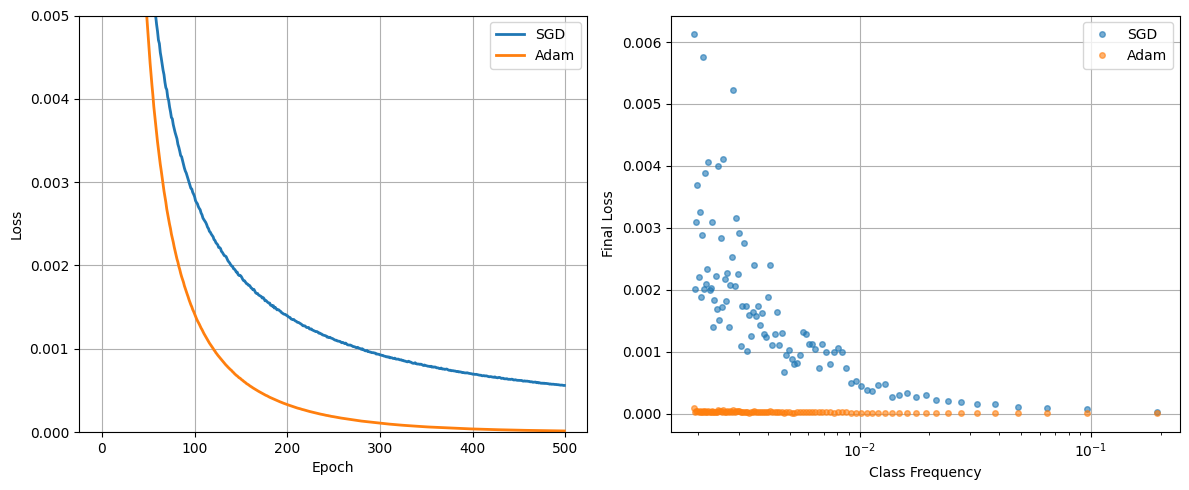

In [13]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_sgd, label='SGD', linewidth=2)
plt.plot(loss_adam, label='Adam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.ylim(0, 0.005)

plt.subplot(1, 2, 2)
sorted_idx = np.argsort(class_probs)[::-1]
plt.semilogx(class_probs[sorted_idx], perclass_sgd[sorted_idx], 'o', label='SGD', alpha=0.6, markersize=4)
plt.semilogx(class_probs[sorted_idx], perclass_adam[sorted_idx], 'o', label='Adam', alpha=0.6, markersize=4)
plt.xlabel('Class Frequency')
plt.ylabel('Final Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Сбалансированный MNIST (по 1000 примеров на класс)
balanced_data = []
balanced_targets = []
for class_idx in range(10):
    idx = (full_mnist.targets == class_idx).nonzero(as_tuple=True)[0]
    selected = idx[:1000]
    balanced_data.append(full_mnist.data[selected])
    balanced_targets.append(full_mnist.targets[selected])

X_balanced = torch.cat(balanced_data, dim=0).float().view(-1, 28*28) / 255.0
y_balanced = torch.cat(balanced_targets, dim=0)

perm = torch.randperm(len(X_balanced))
X_balanced, y_balanced = X_balanced[perm], y_balanced[perm]

print(f"Balanced MNIST: {len(X_balanced)} samples, {Counter(y_balanced.tolist())}")

Balanced MNIST: 10000 samples, Counter({2: 1000, 3: 1000, 4: 1000, 9: 1000, 6: 1000, 1: 1000, 0: 1000, 7: 1000, 8: 1000, 5: 1000})


In [15]:
def train_mnist_fast(X, y, optimizer_name='sgd', lr=0.01, epochs=200, batch_size=256):
    model = nn.Linear(784, 10).to(device)
    X, y = X.to(device), y.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr) if optimizer_name == 'adam' else optim.SGD(model.parameters(), lr=lr)

    history_loss = []

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X))
        epoch_loss = 0
        batches = 0

        for i in range(0, len(X), batch_size):
            idx = perm[i:i+batch_size]
            loss = criterion(model(X[idx]), y[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            batches += 1

        history_loss.append(epoch_loss / batches)
        if (epoch+1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {history_loss[-1]:.4f}")

    return history_loss

print("=== Balanced MNIST SGD ===")
loss_bal_sgd = train_mnist_fast(X_balanced, y_balanced, 'sgd', lr=0.5, epochs=200)

print("\n=== Balanced MNIST Adam ===")
loss_bal_adam = train_mnist_fast(X_balanced, y_balanced, 'adam', lr=0.001, epochs=200)

=== Balanced MNIST SGD ===
  Epoch 50/200, Loss: 0.2130
  Epoch 100/200, Loss: 0.1749
  Epoch 150/200, Loss: 0.1567
  Epoch 200/200, Loss: 0.1470

=== Balanced MNIST Adam ===
  Epoch 50/200, Loss: 0.2307
  Epoch 100/200, Loss: 0.1769
  Epoch 150/200, Loss: 0.1524
  Epoch 200/200, Loss: 0.1380


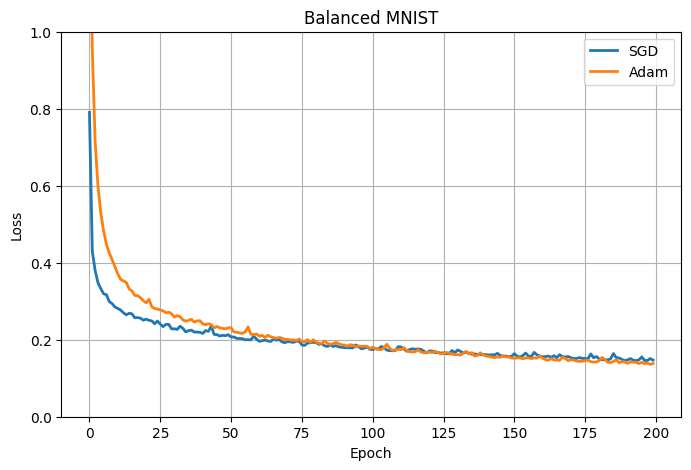

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(loss_bal_sgd, label='SGD', linewidth=2)
plt.plot(loss_bal_adam, label='Adam', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.title('Balanced MNIST')
plt.show()